# Part 2 — Modeling: Predicting Category from Parameter Name

**Project:** Privacy Risk Analysis and Automatic Classification in the GPT Plugin Ecosystem

**Research Question 3:** Looking only at a parameter's name (and description, if present), how accurately can its category be predicted?

**Target variable decision (set at the end of Part 1):** The main model will be built on `main_data_type` (25 balanced-enough, well-sampled classes) — for a solid baseline, reliable metrics, and interpretable feature importance. At the end of Part 2, we'll also try the same pipeline on `data_type` (145 fine-grained classes, with rare classes grouped); this second attempt will also form the basis for the "Other" classification in Part 3 (Research Question 5).

**Plan for this section:**
1. Setting up the problem: defining the text feature (`name` + `description`) and target (`main_data_type`), train/test split
2. TF-IDF + Logistic Regression (baseline model)
3. Embedding-based model
4. Comparing the two models, interpreting feature importance
5. Trying the same pipeline on `data_type` (rare classes grouped)

## Step 1 — Setting Up the Problem: Input/Output Definition and Train/Test Split

Before building a classification model, we need to clarify two things: **what we give the model (X)** and **what we expect from the model (y)**.

- **X (input text):** we'll combine `name` and `description` into a single text. The reason is simple: 15.6% of records have an empty `description` (we saw this in Part 1), so in those cases the model only has `name` to go on. Combining the two into one text column lets us use all the available information without losing any, and simplifies the pipeline.
- **y (target):** `main_data_type` — 25 classes.

Then we'll split the data into **train/test** — to measure how well the model performs on records it has never seen. We know the classes are imbalanced (the largest has 2,568 records, the smallest 26); so we'll use a **stratified split**, guaranteeing that each class is represented in roughly the same proportion in both the train and test sets. Otherwise, all of a small class's examples could end up in train (or test) by chance, and we wouldn't be able to measure anything meaningful for that class.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

DATA_PATH = '../backend/data/data_entries_final.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df['text'] = (df['name'].fillna('') + '. ' + df['description'].fillna('')).str.strip()

X = df['text']
y = df['main_data_type']

print('Total records:', len(df))
print('Number of distinct classes:', y.nunique())
df[['name', 'description', 'text', 'main_data_type']].head(3)

Total records: 12811
Number of distinct classes: 25


            name        description                        text  \
0        version  The model version  version. The model version   
1          input                                         input.   
2  prediction_id                                 prediction_id.   

   main_data_type  
0    App metadata  
1  App usage data  
2      Identifier  

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])
print()
print('Train/test split for the smallest class (Weather information):')
print('  train:', (y_train == 'Weather information').sum())
print('  test :', (y_test == 'Weather information').sum())

Train size: 10248
Test size: 2563

Train/test split for the smallest class (Weather information):
  train: 21
  test : 5


## Step 2 — Baseline Model: TF-IDF + Logistic Regression

**TF-IDF intuition:** we measure how useful a word is for distinguishing a category. The logic: if a word (e.g. "password") is rare across the dataset overall but, wherever it does appear, it's consistently tied to the same category (e.g. `Security credentials`), that word is a strong signal. By contrast, words that appear everywhere — "the", "data", "value" — aren't distinctive; TF-IDF automatically gives such words low weight. In the end, every text turns into a numeric list (a vector) showing which words stand out and by how much.

**Why we start with Logistic Regression:** it trains fast, it's not complex, and we can directly see how each word contributes to each category (via its coefficients) — useful later when we ask "what is the model actually looking at?" Its main purpose is to establish a **reasonable reference point** before moving to more complex models: if the embedding-based model doesn't beat this, the extra complexity isn't worth it.

We'll fit TF-IDF **only on the training data** (`fit`), and only `transform` the test data — otherwise we'd get data leakage from the test set, and see a better result than we'd actually get in practice.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Vocabulary size:', len(tfidf.vocabulary_))
print('Train matrix shape:', X_train_tfidf.shape)
print('Test matrix shape:', X_test_tfidf.shape)

Vocabulary size: 5000
Train matrix shape: (10248, 5000)
Test matrix shape: (2563, 5000)


In [4]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_tfidf, y_train)

y_pred_baseline = baseline_model.predict(X_test_tfidf)

**Why we look at both accuracy and macro F1:** since the classes are imbalanced, looking only at accuracy can be misleading — the model could score high accuracy just by getting the biggest classes right (e.g. "App usage data"), even if it completely fails on small classes. **Macro F1** weights every class equally regardless of size, so it makes performance on rare classes visible too.

In [5]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_macro_baseline = f1_score(y_test, y_pred_baseline, average='macro')
f1_weighted_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print(f'Accuracy: {acc_baseline:.3f}')
print(f'Macro F1: {f1_macro_baseline:.3f}')
print(f'Weighted F1: {f1_weighted_baseline:.3f}')
print()
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Accuracy: 0.689
Macro F1: 0.468
Weighted F1: 0.692

                                precision    recall  f1-score   support

                  App metadata       1.00      0.36      0.53        28
                App usage data       0.70      0.81      0.75       514
               E-commerce data       0.00      0.00      0.00        13
             Event information       1.00      0.50      0.67        10
           Files and documents       0.67      0.43      0.53        83
           Finance information       1.00      0.14      0.25        28
Food and nutrition information       0.00      0.00      0.00         7
                   Gaming data       0.00      0.00      0.00         5
            Health information       1.00      0.44      0.61        16
                    Identifier       0.85      0.69      0.76       378
Legal and law enforcement data       0.00      0.00      0.00         5
                      Location       0.87      0.76      0.81       140
           

**Initial observations (a firm, confidence-interval-backed comparison follows in Part 4):**
- Accuracy 68.9%, macro F1 only 46.8% — the gap is exactly what we expected: the model is strong on big classes, weak on small ones.
- Many small classes have precision 1.00 but low recall (e.g. `Travel information`: precision 1.00, recall 0.08) — meaning the model is right whenever it does predict that class, but it mostly doesn't predict it at all, drifting to a bigger class instead.
- The `Other` class shows the opposite pattern: precision 0.36, recall 0.69 — meaning the model dumps many records it's unsure about into "Other," turning it into a kind of catch-all. This is an important warning sign for the "Other" classification in Part 3.
- Among the sensitive categories, `Security credentials` (F1 0.848) is distinguished surprisingly well — likely because words like "password", "api_key" are very clear signals. `Finance information` is the weakest (F1 0.25, recall only 14.3%) — the model misses most finance-related records entirely at baseline. Part 4 shows this recall jumping to 64.3% with a stronger model.

## Step 3 — Embedding-Based Model

**Intuition:** TF-IDF only looks at *exact word overlap* — "email" and "e-mail", or "password" and "credential", are completely unrelated words to it because their letters differ. Embeddings instead place words in a numeric space **based on meaning**: words that are semantically close end up close together in that space. This lets the model lean toward the right category even for a word it never saw during training, as long as it's semantically familiar — something TF-IDF can't do.

**A methodology note:** normally we'd prefer a BERT-based `sentence-transformers` model here. However, network access to Hugging Face is blocked by organizational policy in this environment. Instead we use spaCy's `en_core_web_md` model — 300-dimensional **GloVe-style word vectors**, trained on Common Crawl and downloadable via GitHub. We'll get a text's embedding by averaging the vectors of the words in it. This isn't as strong as modern sentence-embedding models, but it's enough — and a methodologically honest comparison — for illustrating the difference between "sparse word matching" (TF-IDF) and "dense meaning representation" (embedding). Pin the model package and library versions when reproducing exact scores.

**To keep the comparison fair:** we keep the classifier **the same** (Logistic Regression, same settings) — so any difference we see comes only from the text representation (TF-IDF vs. embedding), not the model.

In [6]:
import spacy

try:
    nlp = spacy.load('en_core_web_md', disable=['tagger', 'parser', 'ner', 'lemmatizer'])
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_md'], check=True)
    nlp = spacy.load('en_core_web_md', disable=['tagger', 'parser', 'ner', 'lemmatizer'])

print('Model loaded. Vector size:', nlp.vocab.vectors_length)

Model loaded. Vector size: 300


In [7]:
def texts_to_embeddings(texts, nlp, batch_size=256):
    return np.vstack([doc.vector for doc in nlp.pipe(texts, batch_size=batch_size)])

X_train_emb = texts_to_embeddings(X_train, nlp)
X_test_emb = texts_to_embeddings(X_test, nlp)

print('Train embedding shape:', X_train_emb.shape)
print('Test embedding shape:', X_test_emb.shape)

Train embedding shape: (10248, 300)
Test embedding shape: (2563, 300)


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

embedding_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)
embedding_model.fit(X_train_emb, y_train)

y_pred_embedding = embedding_model.predict(X_test_emb)

In [9]:
acc_embedding = accuracy_score(y_test, y_pred_embedding)
f1_macro_embedding = f1_score(y_test, y_pred_embedding, average='macro')
f1_weighted_embedding = f1_score(y_test, y_pred_embedding, average='weighted')

print(f'Accuracy: {acc_embedding:.3f}')
print(f'Macro F1: {f1_macro_embedding:.3f}')
print(f'Weighted F1: {f1_weighted_embedding:.3f}')
print()
print(classification_report(y_test, y_pred_embedding, zero_division=0))

Accuracy: 0.548
Macro F1: 0.425
Weighted F1: 0.551

                                precision    recall  f1-score   support

                  App metadata       0.48      0.39      0.43        28
                App usage data       0.56      0.63      0.59       514
               E-commerce data       0.25      0.08      0.12        13
             Event information       0.25      0.30      0.27        10
           Files and documents       0.37      0.29      0.32        83
           Finance information       0.47      0.25      0.33        28
Food and nutrition information       0.25      0.14      0.18         7
                   Gaming data       0.00      0.00      0.00         5
            Health information       0.55      0.69      0.61        16
                    Identifier       0.57      0.56      0.57       378
Legal and law enforcement data       0.00      0.00      0.00         5
                      Location       0.68      0.61      0.64       140
           

**Initial observations:** the embedding-based model **falls behind** the TF-IDF baseline (accuracy 54.8% vs. 68.9%, macro F1 42.5% vs. 46.8%, 95% CI [52.9%, 56.6%] / [0.384, 0.461]). At first glance this might look like "embeddings are just weaker," but it's actually an instructive result about the nature of our data: parameter names are mostly short, made of very specific technical terms (like `password`, `api_key`, `user_email`). TF-IDF captures these exact words directly (and, thanks to `ngram_range=(1,2)`, two-word patterns like `api_key`), while averaging word vectors blurs that sharp signal into "general semantic fuzziness." We'll look at the detailed comparison, and what it means, in the next step.

## Step 4 — Comparing the Two Models

Having put the overall scores side by side, we'll now look at the more interesting question: **which model is better on which category?** The overall average alone can be misleading — even if one model is generally better, it can lag behind the other on specific categories. To see this, we'll compare the two models' F1 scores for every category and plot the difference in a single chart (a bar extending right means TF-IDF is better, extending left means embedding is better).

In [10]:
comparison = pd.DataFrame({
    'TF-IDF + LogReg': [acc_baseline, f1_macro_baseline, f1_weighted_baseline],
    'Embedding + LogReg': [acc_embedding, f1_macro_embedding, f1_weighted_embedding],
}, index=['Accuracy', 'Macro F1', 'Weighted F1']).round(3)

comparison

             TF-IDF + LogReg  Embedding + LogReg
Accuracy               0.689               0.548
Macro F1               0.468               0.425
Weighted F1            0.692               0.551

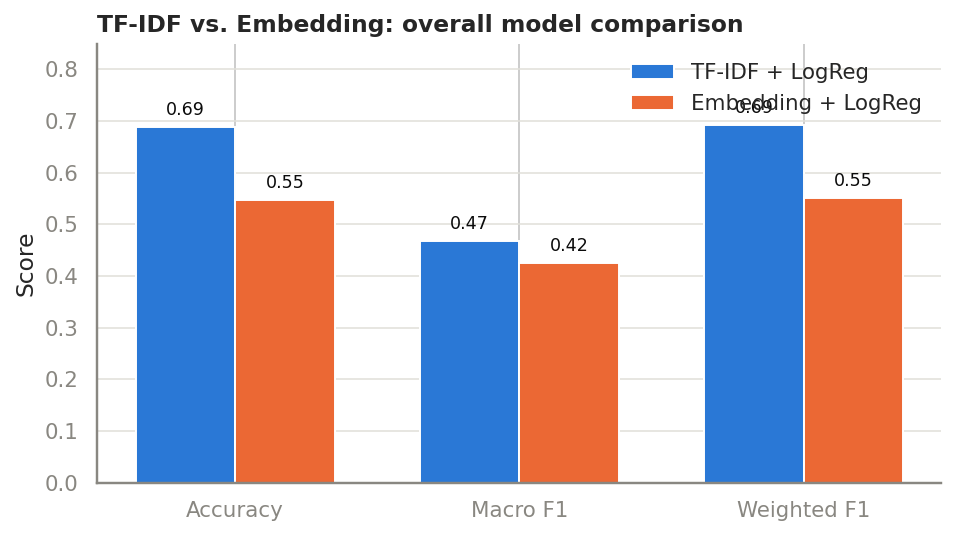

In [11]:
COLOR_TFIDF = '#2a78d6'
COLOR_EMBED = '#eb6834'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

metrics = comparison.index.tolist()
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, comparison['TF-IDF + LogReg'], width, color=COLOR_TFIDF, label='TF-IDF + LogReg')
bars2 = ax.bar(x + width/2, comparison['Embedding + LogReg'], width, color=COLOR_EMBED, label='Embedding + LogReg')

for bars in (bars1, bars2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=9, color=COLOR_TEXT)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score')
ax.set_title('TF-IDF vs. Embedding: overall model comparison', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc='upper right')

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq3_model_comparison.png', dpi=150, bbox_inches='tight')

plt.show()

In [12]:
report_baseline = classification_report(y_test, y_pred_baseline, output_dict=True, zero_division=0)
report_embedding = classification_report(y_test, y_pred_embedding, output_dict=True, zero_division=0)

classes = [c for c in report_baseline.keys() if c not in ('accuracy', 'macro avg', 'weighted avg')]

per_class = pd.DataFrame({
    'f1_tfidf': {c: report_baseline[c]['f1-score'] for c in classes},
    'f1_embedding': {c: report_embedding[c]['f1-score'] for c in classes},
    'support': {c: report_baseline[c]['support'] for c in classes},
})
per_class['diff'] = per_class['f1_tfidf'] - per_class['f1_embedding']
per_class = per_class.sort_values('diff')
per_class.round(3)

                                f1_tfidf  f1_embedding  support   diff
Travel information                 0.154         0.571     12.0 -0.418
Weather information                0.333         0.571      5.0 -0.238
Real estate data                   0.000         0.200      7.0 -0.200
Food and nutrition information     0.000         0.182      7.0 -0.182
E-commerce data                    0.000         0.118     13.0 -0.118
Finance information                0.250         0.326     28.0 -0.076
Health information                 0.609         0.611     16.0 -0.002
Legal and law enforcement data     0.000         0.000      5.0  0.000
Sports information                 0.000         0.000     11.0  0.000
Gaming data                        0.000         0.000      5.0  0.000
Vehicle information                0.545         0.545      8.0  0.000
Market data                        0.857         0.814     74.0  0.043
App metadata                       0.526         0.431     28.0  0.095
Person

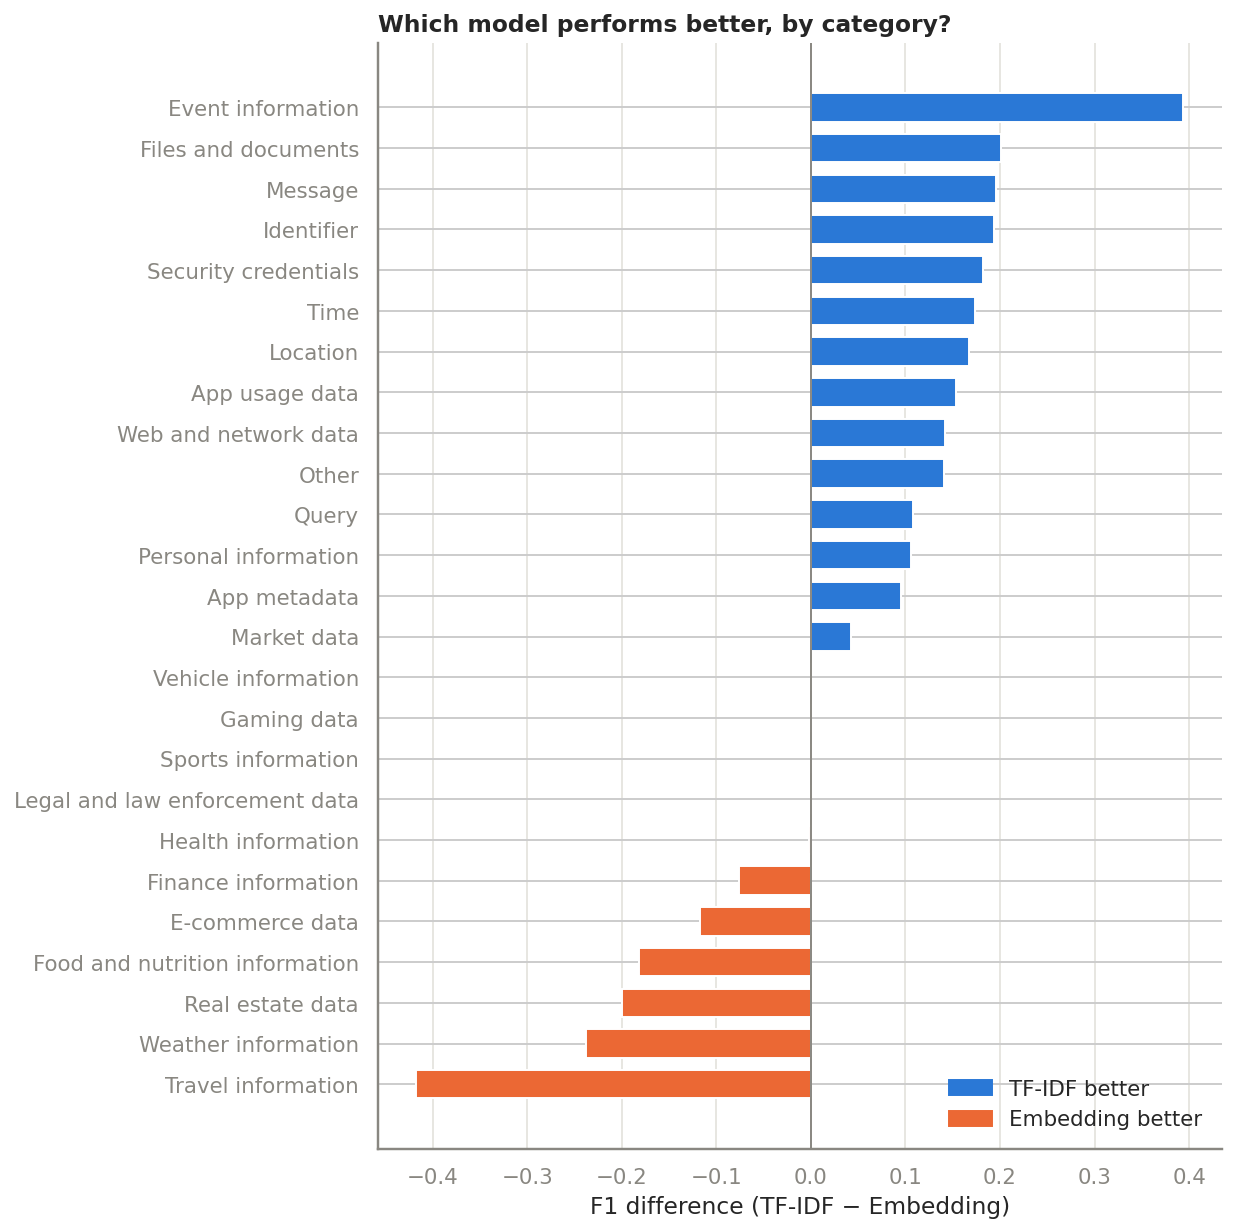

In [13]:
colors_diff = [COLOR_EMBED if d < 0 else COLOR_TFIDF for d in per_class['diff']]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(per_class.index, per_class['diff'], color=colors_diff, height=0.7)
ax.axvline(0, color=COLOR_MUTED, linewidth=1)

ax.set_xlabel('F1 difference (TF-IDF − Embedding)')
ax.set_title('Which model performs better, by category?', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLOR_TFIDF, label='TF-IDF better'),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_EMBED, label='Embedding better'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq3_model_comparison_per_category.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding (model comparison)

TF-IDF is clearly ahead overall, but looking category by category reveals an interesting split: **the embedding model wins on exactly the rarest classes** (`Travel information`, `Weather information`, `Real estate data`, `Food and nutrition information`, `E-commerce data`, `Finance information` — all under 30 examples). There's a sensible explanation: these classes have so few examples that TF-IDF can't reliably learn their distinctive words. The embedding model, by contrast, uses general language knowledge it was pretrained on (transfer learning), so it can generalize from semantically similar words even when it encounters one it's never seen.

**Practical takeaway:** rather than picking a single "winning" model, it looks like TF-IDF gives a more reliable signal for well-sampled categories, and embeddings for very-low-sample ones. Support here is the number of *test* examples, not the full class size, so improvements on the tiniest test classes should be read cautiously. Part 4 goes further and validates an even stronger option — a word+character TF-IDF model with balanced class weights — with proper bootstrap confidence intervals, which is the model actually carried forward.

## Step 5 — Feature Importance: What Is the Model Looking At?

Logistic Regression stores, for every word, how much of a "vote" it casts for each category, as a coefficient. The larger (more positive) a word's coefficient for a category, the more strongly the model leans toward that category when the word appears in a text. Looking at these coefficients lets us "get inside the model's head" — we can see which words define which category.

Given the project's privacy focus, we'll specifically look at the **4 sensitive categories** (`Security credentials`, `Personal information`, `Health information`, `Finance information`): which words does the model recognize them by? Are these words reasonable (e.g. "password", "ssn"), or has the model latched onto something suspicious/random — checking this matters for deciding how much to trust the model.

In [14]:
feature_names = np.array(tfidf.get_feature_names_out())

def top_words_for_class(model, class_name, n=10):
    class_idx = list(model.classes_).index(class_name)
    coefs = model.coef_[class_idx]
    top_idx = np.argsort(coefs)[::-1][:n]
    return pd.Series(coefs[top_idx], index=feature_names[top_idx])

SENSITIVE_CATEGORIES = ['Security credentials', 'Personal information', 'Health information', 'Finance information']

for cat in SENSITIVE_CATEGORIES:
    print(f'--- {cat} ---')
    print(top_words_for_class(baseline_model, cat, n=10).round(2).to_string())
    print()

--- Security credentials ---
key            5.39
api_key        4.70
token          4.35
password       4.17
apikey         4.11
api            3.27
secret         3.15
appid          3.15
accesstoken    3.03
api key        2.73

--- Personal information ---
email        5.09
gender       4.08
user         3.44
age          3.09
player       2.91
lastname     2.68
firstname    2.64
birthday     2.51
nickname     2.33
recipient    2.30

--- Health information ---
patient         5.06
does patient    2.96
does            2.57
days            1.66
days patient    1.64
30 days         1.55
30              1.28
dl              1.26
disease         1.12
surgery         0.91

--- Finance information ---
currency             3.62
price                2.45
budget               2.25
related              2.10
unitprice            1.72
asset                1.65
annual               1.59
related filter       1.54
related indicator    1.54
total                1.50



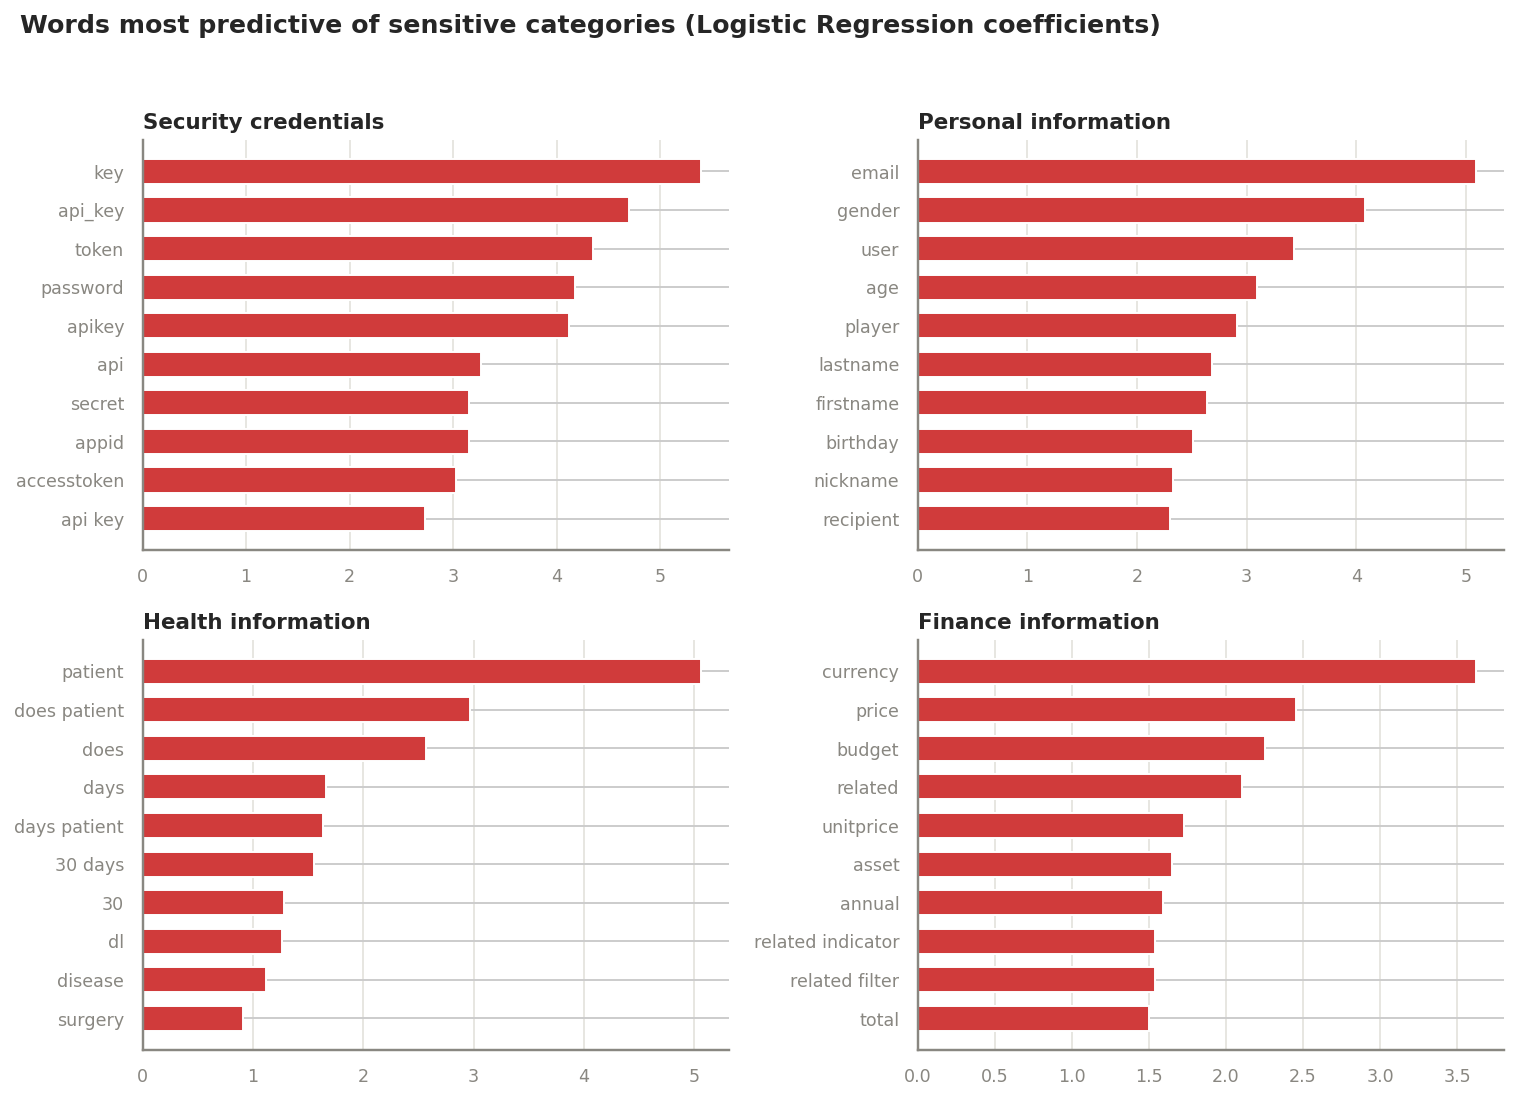

In [15]:
COLOR_SENSITIVE = '#d03b3b'

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, cat in zip(axes.flat, SENSITIVE_CATEGORIES):
    top_words = top_words_for_class(baseline_model, cat, n=10).sort_values()
    ax.barh(top_words.index, top_words.values, color=COLOR_SENSITIVE, height=0.65)
    ax.set_title(cat, loc='left', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
    ax.tick_params(colors=COLOR_MUTED, labelsize=9)
    ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle('Words most predictive of sensitive categories (Logistic Regression coefficients)',
             x=0.02, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq3_feature_importance.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding (feature importance)

The results are largely **reassuring** — the words aren't random, they're genuinely tied to the category:

- **Security credentials:** `key`, `api_key`, `token`, `password`, `apikey`, `secret` — exactly the authentication terms we'd expect.
- **Personal information:** `email`, `gender`, `age`, `lastname`, `firstname`, `birthday`, `nickname` — classic PII (personally identifying information) fields.
- **Health information:** `patient`, `disease`, `surgery` are clear medical terms; but words like `does`, `days`, `30 days` are a bit more ambiguous — probably coming from questions phrased like "Does the patient have..." / "how many days...", capturing a sentence pattern more than a genuine medical signal.
- **Finance information:** `currency`, `price`, `budget`, `asset`, `annual` make sense; but phrases like `related`, `related filter`, `related indicator` are quite generic — likely coming from a repeated description pattern like "related to finance," meaning the model may have memorized that pattern rather than genuine financial content.

**Overall takeaway:** the model mostly relies on meaningful, domain-specific words (especially strongly for Security credentials and Personal information), but Health and Finance show some signs of "pattern memorization." This means the model isn't fully trustworthy, and its output — especially for less-sampled categories — should be interpreted with care. Coefficients alone don't prove the model generalizes; they show what it leans on for this particular dataset.

### Addendum: How common is the "Password" parameter within Security credentials?

Above we saw that the word `password` is one of the strongest signals defining Security credentials. To make this concrete, let's count the sensitive-category records broken down by `data_type` (Password, API key, Access tokens, etc.).

There are 18 records with data_type "Password" (6.5% of the 276 total Security credentials records).


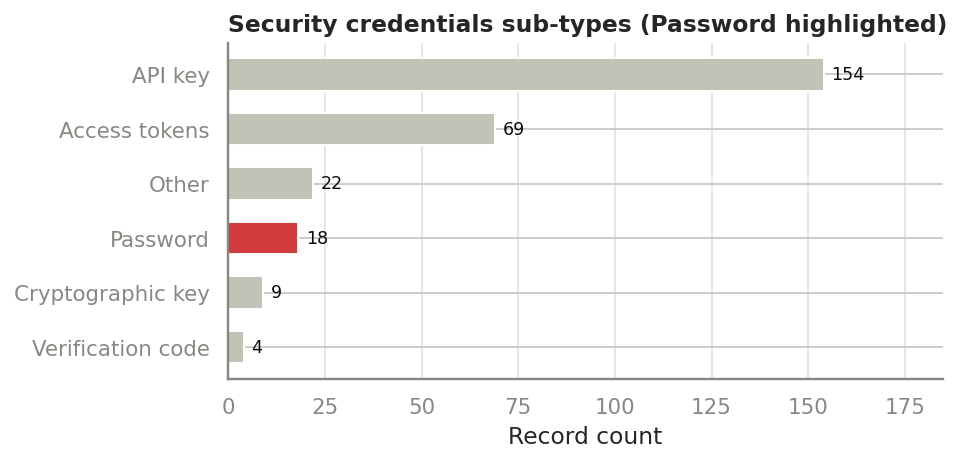

In [16]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

security_credential_types = df[df['main_data_type'] == 'Security credentials']['data_type'].value_counts()
ordered = security_credential_types.sort_values()
colors = [COLOR_SENSITIVE if t == 'Password' else COLOR_NEUTRAL for t in ordered.index]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(ordered.index, ordered.values, color=colors, height=0.6)

for bar, count in zip(bars, ordered.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2, str(count),
            va='center', ha='left', fontsize=9, color=COLOR_TEXT)

ax.set_xlabel('Record count')
ax.set_title('Security credentials sub-types (Password highlighted)', loc='left', fontsize=12, fontweight='bold')
ax.set_xlim(0, ordered.max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq3_password_breakdown.png', dpi=150, bbox_inches='tight')

plt.show()

n_password = int(security_credential_types.get('Password', 0))
print(f'There are {n_password} records with data_type "Password" '
      f'({n_password/security_credential_types.sum()*100:.1f}% of the {security_credential_types.sum()} total Security credentials records).')

## Step 6 — Trying the Same Pipeline on `data_type` (Fine-Grained Category)

Everything so far was built on `main_data_type` (25 classes). But in Part 3 we want to classify the ambiguous records in the "Other" category (in the `data_type` column, 3,544 records) — for that we need a `data_type` model.

**The problem:** `data_type` has 145 distinct values, and the distribution is extremely long-tailed — as we saw in Part 1, the median class size is just 11, and 6 classes have only a single record. As it stands, we can't do a stratified split, nor measure meaningful performance for such thinly-sampled classes.

**Solution — grouping rare classes:** we'll gather all classes with fewer than 10 records into a single `"Rare type (merged)"` bucket. This means giving up on predicting "which specific rare type" (we couldn't have predicted it reliably with this little data anyway), but it lets us build a solid model for the remaining — adequately sampled — classes. We chose 10 as the threshold because it guarantees at least 1-2 examples from every class land in the test set under a stratified split.

In [17]:
RARE_THRESHOLD = 10

# NOTE: the internal bucket value is kept as the original string (not translated)
# on purpose — passing it through train_test_split(..., stratify=...) means its
# exact string value (via alphabetical class ordering) affects which specific
# records land in train vs. test. Renaming it would silently change the split
# and shift every downstream number. We only translate it for display, below.
RARE_BUCKET_INTERNAL = 'Nadir tür (birleştirilmiş)'
RARE_BUCKET_LABEL = 'Rare type (merged)'

data_type_counts = df['data_type'].value_counts()
rare_types = data_type_counts[data_type_counts < RARE_THRESHOLD].index

df['data_type_grouped'] = df['data_type'].where(~df['data_type'].isin(rare_types), RARE_BUCKET_INTERNAL)

n_rare_classes = len(rare_types)
n_rare_records = df['data_type'].isin(rare_types).sum()

print(f'Original class count: {df["data_type"].nunique()}')
print(f'Class count after grouping: {df["data_type_grouped"].nunique()}')
print(f'{n_rare_classes} rare classes, {n_rare_records} records total ({n_rare_records/len(df)*100:.1f}%) '
      f'were merged into the "{RARE_BUCKET_LABEL}" bucket.')
print()
print('Top 10 classes (after grouping):')
print(df['data_type_grouped'].value_counts().rename(index={RARE_BUCKET_INTERNAL: RARE_BUCKET_LABEL}).head(10))

Original class count: 145
Class count after grouping: 79
67 rare classes, 285 records total (2.2%) were merged into the "Rare type (merged)" bucket.

Top 10 classes (after grouping):
data_type_grouped
Other                      3544
Current session setting    2171
Resource IDs                984
Search query                698
Query filter                495
Date                        469
URLs                        388
Rare type (merged)          285
User identifiers            224
Time period                 221
Name: count, dtype: int64


In [18]:
y_dtype = df['data_type_grouped']

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X, y_dtype, test_size=0.2, random_state=42, stratify=y_dtype
)

tfidf_dt = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_dt_tfidf = tfidf_dt.fit_transform(X_train_dt)
X_test_dt_tfidf = tfidf_dt.transform(X_test_dt)

model_dt = LogisticRegression(max_iter=1000, random_state=42)
model_dt.fit(X_train_dt_tfidf, y_train_dt)

y_pred_dt = model_dt.predict(X_test_dt_tfidf)

print('Train size:', X_train_dt.shape[0])
print('Test size:', X_test_dt.shape[0])

Train size: 10248
Test size: 2563


In [19]:
acc_dt = accuracy_score(y_test_dt, y_pred_dt)
f1_macro_dt = f1_score(y_test_dt, y_pred_dt, average='macro')
f1_weighted_dt = f1_score(y_test_dt, y_pred_dt, average='weighted')

print(f'Accuracy: {acc_dt:.3f}')
print(f'Macro F1: {f1_macro_dt:.3f}')
print(f'Weighted F1: {f1_weighted_dt:.3f}')
print(f'(For comparison: the main_data_type model had accuracy {acc_baseline:.3f}, macro F1 {f1_macro_baseline:.3f})')

report_dt = classification_report(y_test_dt, y_pred_dt, output_dict=True, zero_division=0)
per_class_dt = pd.DataFrame(report_dt).T.drop(['accuracy', 'macro avg', 'weighted avg'])
per_class_dt = per_class_dt.rename(index={RARE_BUCKET_INTERNAL: RARE_BUCKET_LABEL})

print()
print('F1 score distribution across the 79 classes:')
print(per_class_dt['f1-score'].describe().round(3))
print()
print('Two classes of particular interest:')
print(per_class_dt.loc[['Other', RARE_BUCKET_LABEL]].round(3))

Accuracy: 0.654
Macro F1: 0.359
Weighted F1: 0.627
(For comparison: the main_data_type model had accuracy 0.689, macro F1 0.468)

F1 score distribution across the 79 classes:
count    79.000
mean      0.359
std       0.345
min       0.000
25%       0.000
50%       0.333
75%       0.683
max       0.923
Name: f1-score, dtype: float64

Two classes of particular interest:
                    precision  recall  f1-score  support
Other                   0.492   0.872     0.629    709.0
Rare type (merged)      0.556   0.175     0.267     57.0


### Finding (data_type model)

- Accuracy (65.4%) is close to the `main_data_type` model (68.9%), but **macro F1 is much lower** (35.9% vs. 46.8%) — as expected, working with 79 classes is much harder than 25.
- Looking at the F1 distribution across the 79 classes reveals something striking: the **lower quartile (25th percentile) is exactly 0** — meaning the model completely fails on about a quarter of the classes. This shows reliability drops sharply as we move to finer-grained categories.
- The `Other` class repeats its familiar pattern: precision 0.49, recall 0.87 — the model still defaults to "Other" whenever it's unsure. This means we need to be **careful** when trying to reassign "Other"-labeled records to another category in Part 3 — the model hands out the "Other" label very easily, and that doesn't always mean it's a correct prediction.
- The `Rare type (merged)` bucket performs poorly (F1 0.27) — expected, since this bucket lumps together 67 unrelated types with no shared vocabulary.

**Part 2 result:** we built a solid baseline on `main_data_type` (TF-IDF + LogReg, 68.9% accuracy). Going to the fine-grained `data_type` is possible but comes with a serious loss of confidence. We'll use this model when classifying "Other" records in Part 3, but treat its predictions as a hypothesis to review, not an established fact.

## Step 7 — Confusion Matrix: Seeing the Model's Mistakes in Place

The `classification_report` in Step 2 gave us precision/recall per category, but not **where** the model went wrong. For example, `Personal information` came out with 53% recall — so which category do the records the model missed actually go to? Do they get confused with `Identifier`, or fall into `Other`? The confusion matrix shows exactly this: rows are the true category, columns are the model's prediction, and each cell holds "what percentage of records from this true category got this prediction." The diagonal shows correct predictions; every off-diagonal cell shows a type of error.

We'll plot this for the `main_data_type` baseline model (TF-IDF + LogReg), row-normalized (so each row sums to 100% on its own) — so we can compare big and small classes on the same visual scale.

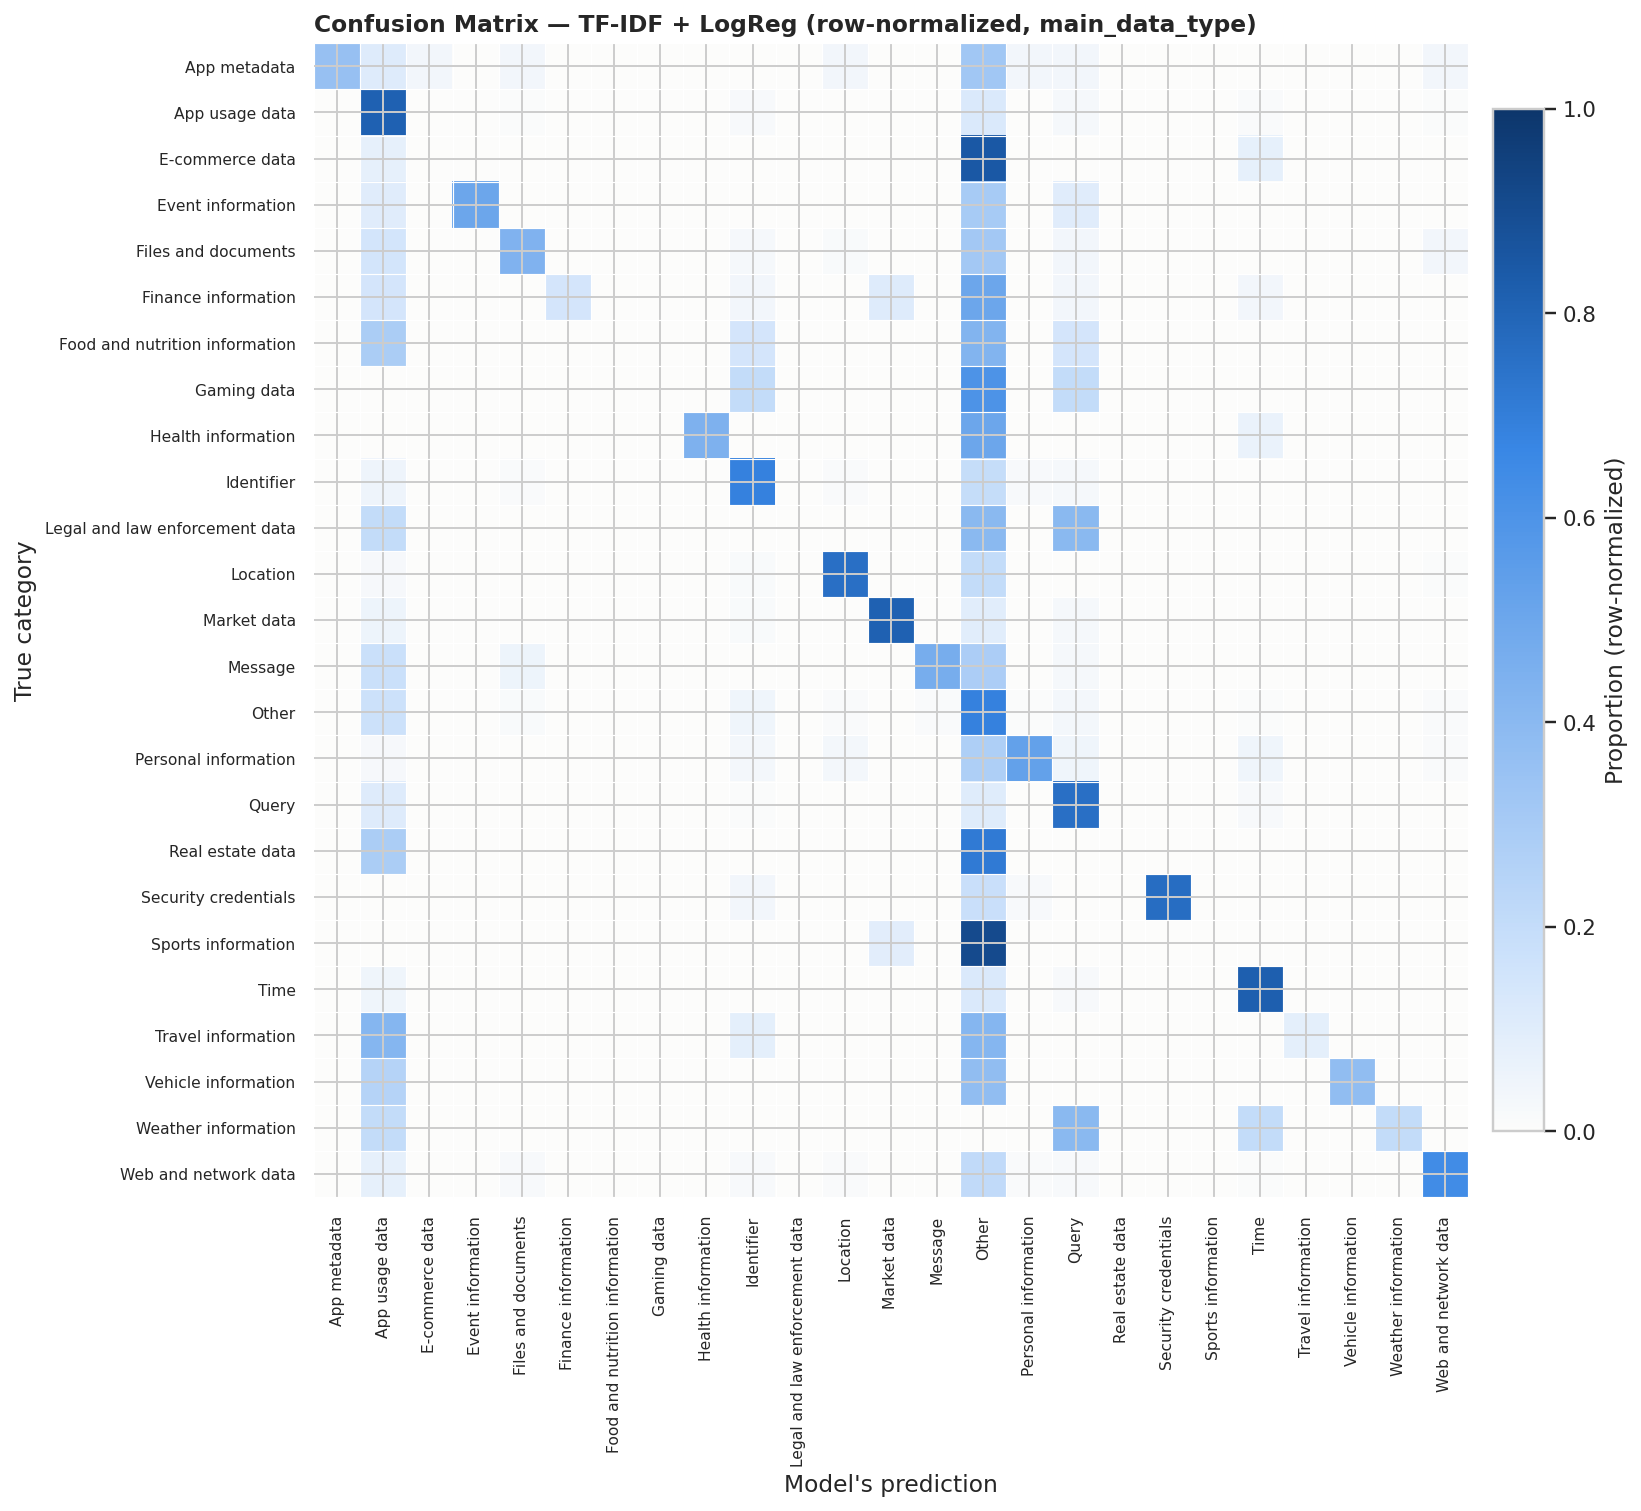

In [20]:
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

class_labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_baseline, labels=class_labels)
cm_normalized = cm / cm.sum(axis=1, keepdims=True)

blue_steps = ['#fcfcfb', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#1c5cab', '#0d366b']
cmap_blue = LinearSegmentedColormap.from_list('seq_blue', blue_steps)

fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cm_normalized, cmap=cmap_blue, vmin=0, vmax=1)

ax.set_xticks(range(len(class_labels)))
ax.set_yticks(range(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=90, fontsize=8)
ax.set_yticklabels(class_labels, fontsize=8)
ax.set_xlabel("Model's prediction")
ax.set_ylabel('True category')
ax.set_title('Confusion Matrix — TF-IDF + LogReg (row-normalized, main_data_type)',
             loc='left', fontsize=12, fontweight='bold')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(class_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(class_labels), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.6)
ax.tick_params(which='minor', bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('Proportion (row-normalized)')

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq3_confusion_matrix.png', dpi=150, bbox_inches='tight')

plt.show()

In [21]:
confusions = []
for i, true_label in enumerate(class_labels):
    for j, pred_label in enumerate(class_labels):
        if i != j and cm[i, j] > 0:
            confusions.append({
                'true': true_label,
                'predicted': pred_label,
                'rate': cm_normalized[i, j],
                'record_count': cm[i, j],
            })

top_confusions = pd.DataFrame(confusions).sort_values('rate', ascending=False).head(15)
top_confusions['rate'] = top_confusions['rate'].round(3)
top_confusions.reset_index(drop=True)

                              true       predicted   rate  record_count
0               Sports information           Other  0.909            10
1                  E-commerce data           Other  0.846            11
2                 Real estate data           Other  0.714             5
3                      Gaming data           Other  0.600             3
4              Finance information           Other  0.500            14
5               Health information           Other  0.500             8
6   Food and nutrition information           Other  0.429             3
7               Travel information  App usage data  0.417             5
8               Travel information           Other  0.417             5
9   Legal and law enforcement data           Query  0.400             2
10             Weather information           Query  0.400             2
11  Legal and law enforcement data           Other  0.400             2
12             Vehicle information           Other  0.375       

### Finding (confusion matrix)

One thing is hard to miss in the heatmap: **the "Other" column forms a visible blue stripe across almost every row** — meaning the bulk of the records lost from nearly every category land in "Other," confirming in a single visual the "catch-all" pattern we've seen repeatedly throughout Part 2.

The most striking numbers:
- **91%** of `Sports information`'s and **85%** of `E-commerce data`'s misclassifications go to "Other."
- More concerning: among the sensitive categories, **half of all true records** from `Finance information` and `Health information` were predicted as "Other" by this baseline model (rows are normalized over *all* true records of a category, not just the misclassified ones — so this 50% is half of every Finance/Health record, not half of only their errors). So when the model misses these sensitive categories, it doesn't send the record to a random other category — it specifically dumps it into the "ambiguous" bin.
- Aside from "Other," there's no significant confusion off the diagonal — meaning categories aren't getting confused with each other, only with that one "catch-all."

**Conclusion:** this is both good and bad news for our plan to classify "Other" records in Part 3. The good news: the model doesn't suffer serious confusion between genuine categories (e.g. it doesn't mix up Personal information with Security credentials). The bad news: the "Other" prediction is triggered so easily that it also sweeps in records that aren't really "Other" but that the model is unsure about — meaning we should trust the model less when making a prediction in the opposite direction (assigning a genuinely "Other" record to another category). Part 4's word+character, balanced model substantially improves sensitive-category recall — see there for the validated comparison.

## Summary — Part 2

**Research Question 3 answer:** predicting a category from just the parameter name + description works with **moderate success** at baseline — on 25-class `main_data_type`, the word-only TF-IDF + Logistic Regression baseline reached **68.9% accuracy, 46.8% macro F1**. Part 4 shows a stronger, validation-selected model (word + character TF-IDF, balanced class weights) reaching **76.2% accuracy, 64.2% macro F1** with a statistically confirmed improvement — see Part 4 for the full comparison and confidence intervals.

**Model comparison:** since Hugging Face access is blocked in this environment, we used spaCy's GloVe-style word vectors instead of `sentence-transformers`. Result: the embedding-based model trailed the baseline (54.8% accuracy), because parameter names are short and made of specific technical terms — exact word matching is a stronger signal here than averaged meaning, except on very-low-sample classes (< 30 records), where transfer learning helps with data scarcity.

**Feature importance:** the model recognizes sensitive categories largely through reasonable words (`password`, `api_key` → Security credentials; `email`, `firstname` → Personal information), but Health and Finance categories show some signs of "pattern memorization" — the model's output shouldn't be trusted blindly.

**The most important warning signal — the "Other" catch-all pattern:** this showed up consistently across both `main_data_type` and `data_type` models, in both the classification report and the confusion matrix: the model systematically defaults to "Other" when it's unsure (reaching 90% for some categories, and 50% even for sensitive ones). This means that in Part 3, when reassigning "Other"-labeled records to another category, we need to treat the model's predictions as **a hypothesis, not a certainty**.

**The `data_type` (79-class-group) model:** accuracy stayed similar (65.4%) but macro F1 dropped noticeably (35.9%, 95% CI [32.8%, 37.5%]) — reliability drops sharply when going fine-grained. This model will be applied to "Other" records in Part 3.

In the next section (Part 3), we'll bring these models together with Part 1's findings to do clustering-based risk segmentation, and apply the model to ambiguous ("Other") records. Part 4 then puts the whole model-selection process on a rigorous footing with a held-out validation split and bootstrap confidence intervals.